# Interprétabilité : SHAP

## Ce que SHAP est, et ce qu'il n'est PAS

**SHAP (SHapley Additive exPlanations)** est fondé sur la théorie des jeux coopératifs (Shapley, 1953).
L'idée : distribuer équitablement le "gain" d'une prédiction entre toutes les features,
en considérant toutes les coalitions possibles de features.

**Ce qu'une valeur SHAP signifie :**
> Pour une instance donnée, la valeur SHAP de la feature $x_j$ représente
> **la contribution marginale de $x_j$ à la prédiction**, par rapport à la
> prédiction de base (moyenne du modèle sur l'ensemble de référence).

**Ce qu'une valeur SHAP ne signifie PAS :**
- Une corrélation entre la feature et le churn
- Un coefficient de régression global
- L'importance de la feature indépendamment des autres

**Formulation correcte :**
- "Pour ce client, un CSAT=1 contribue à **+0.18 logit** de probabilité de churn
  par rapport à la prédiction moyenne du modèle"
-"Une tenure élevée contribue négativement à P(churn) pour ce client"
- ~~"Le CSAT est corrélé au churn"~~
- ~~"La tenure réduit le churn"~~


In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import shap

ROOT        = Path('..').resolve()
MODELS_DIR  = ROOT / 'models'
FIGURES_DIR = ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Charger les artefacts
arts   = joblib.load(MODELS_DIR / 'preprocessing_artifacts.joblib')
mod_a  = joblib.load(MODELS_DIR / 'modeling_artifacts.joblib')

X_test_proc  = arts['X_test_proc']
X_test_raw   = arts['X_test_raw']
y_test       = arts['y_test']
FEATURE_NAMES = arts['feature_names']

best_model_name = mod_a['best_model_name']
best_threshold  = mod_a['best_threshold']
best_pred_test  = mod_a['best_pred_test']
best_proba_test = mod_a['best_proba_test']

print(f'Modèle analysé : {best_model_name}')
print(f'Seuil de décision : {best_threshold:.3f}')
print(f'Features : {len(FEATURE_NAMES)}')

Modèle analysé : Random Forest
Seuil de décision : 0.632
Features : 50


## 1. Chargement du modèle et choix de l'explainer

**Quel explainer SHAP utiliser ?**

| Modèle | Explainer recommandé | Raison |
|---|---|---|
| XGBoost / LightGBM / RF | `TreeExplainer` | Exact, rapide (exploite la structure des arbres) |
| Logistic Regression | `LinearExplainer` | Exact pour les modèles linéaires |
| MLP / modèles arbitraires | `KernelExplainer` | Approximatif, lent (agnostique au modèle) |

On utilise le meilleur modèle sélectionné dans le notebook 03.

In [3]:
def normalize_shap_values(sv):
    """Normalise la sortie SHAP en 2D (n_samples, n_features) pour la classe 1.
    Gere : liste [cls0, cls1], tableau 3D (n, f, 2), tableau 2D direct."""
    if isinstance(sv, list):
        return np.array(sv[1])
    sv = np.array(sv)
    if sv.ndim == 3:
        return sv[:, :, 1]
    return sv

def normalize_base_value(bv):
    """Normalise expected_value en scalaire pour la classe 1."""
    arr = np.array(bv).ravel()
    return float(arr[1]) if len(arr) > 1 else float(arr[0])

# Charger le modele et calculer les valeurs SHAP
if best_model_name == 'MLP (Keras)':
    from tensorflow import keras
    best_model = keras.models.load_model(MODELS_DIR / 'best_model_churn.keras')
    background = shap.kmeans(X_test_proc, 50)
    predict_fn = lambda x: best_model.predict(x, verbose=0).flatten()
    explainer  = shap.KernelExplainer(predict_fn, background)
    idx_sample = np.random.choice(len(X_test_proc), size=min(200, len(X_test_proc)), replace=False)
    X_explain  = X_test_proc[idx_sample]
    print(f'Explainer : KernelExplainer (MLP) — calcul sur {len(X_explain)} instances...')
    shap_values = normalize_shap_values(explainer.shap_values(X_explain))
    base_value  = normalize_base_value(explainer.expected_value)

elif best_model_name in ('XGBoost', 'Random Forest'):
    best_model = joblib.load(MODELS_DIR / 'best_model_churn.joblib')
    explainer  = shap.TreeExplainer(best_model)
    X_explain  = X_test_proc
    idx_sample = np.arange(len(X_test_proc))
    print('Explainer : TreeExplainer (exact, rapide)')
    shap_values = normalize_shap_values(explainer.shap_values(X_explain))
    base_value  = normalize_base_value(explainer.expected_value)

elif best_model_name == 'Logistic Regression':
    best_model = joblib.load(MODELS_DIR / 'best_model_churn.joblib')
    explainer  = shap.LinearExplainer(best_model, X_test_proc)
    X_explain  = X_test_proc
    idx_sample = np.arange(len(X_test_proc))
    print('Explainer : LinearExplainer (exact)')
    raw_sv      = explainer.shap_values(X_explain)
    bv          = explainer.expected_value
    shap_values = normalize_shap_values(raw_sv if isinstance(raw_sv, list) else [None, raw_sv])
    base_value  = normalize_base_value(bv if hasattr(bv, '__len__') else [bv, bv])

# Verification
assert shap_values.ndim == 2, f'shap_values shape inattendue : {shap_values.shape}'
assert shap_values.shape[1] == len(FEATURE_NAMES), 'Nombre de features SHAP incorrect'

shap_df = pd.DataFrame(shap_values, columns=FEATURE_NAMES)

print(f'Matrice SHAP : {shap_df.shape}')
print(f'Valeur de base (prediction moyenne) : {base_value:.4f}')
print('Interpretation : SHAP > 0 → la feature pousse vers churn=1 pour cette instance')

Explainer : TreeExplainer (exact, rapide)
Matrice SHAP : (1500, 50)
Valeur de base (prediction moyenne) : 0.5003
Interpretation : SHAP > 0 → la feature pousse vers churn=1 pour cette instance


## 2. Importance globale : Beeswarm Plot

Le beeswarm montre deux informations simultanément :
- **Axe horizontal** : l'amplitude de la valeur SHAP (contribution à la prédiction)
- **Couleur** : la valeur réelle de la feature (rouge = haute, bleu = basse)

**Lecture correcte :**
"Les points rouges de CSAT_score à gauche signifient que les clients avec un CSAT élevé
ont une contribution SHAP négative → CSAT élevé réduit la contribution à P(churn)".

Ce n'est pas une corrélation globale — c'est une contribution instance par instance.

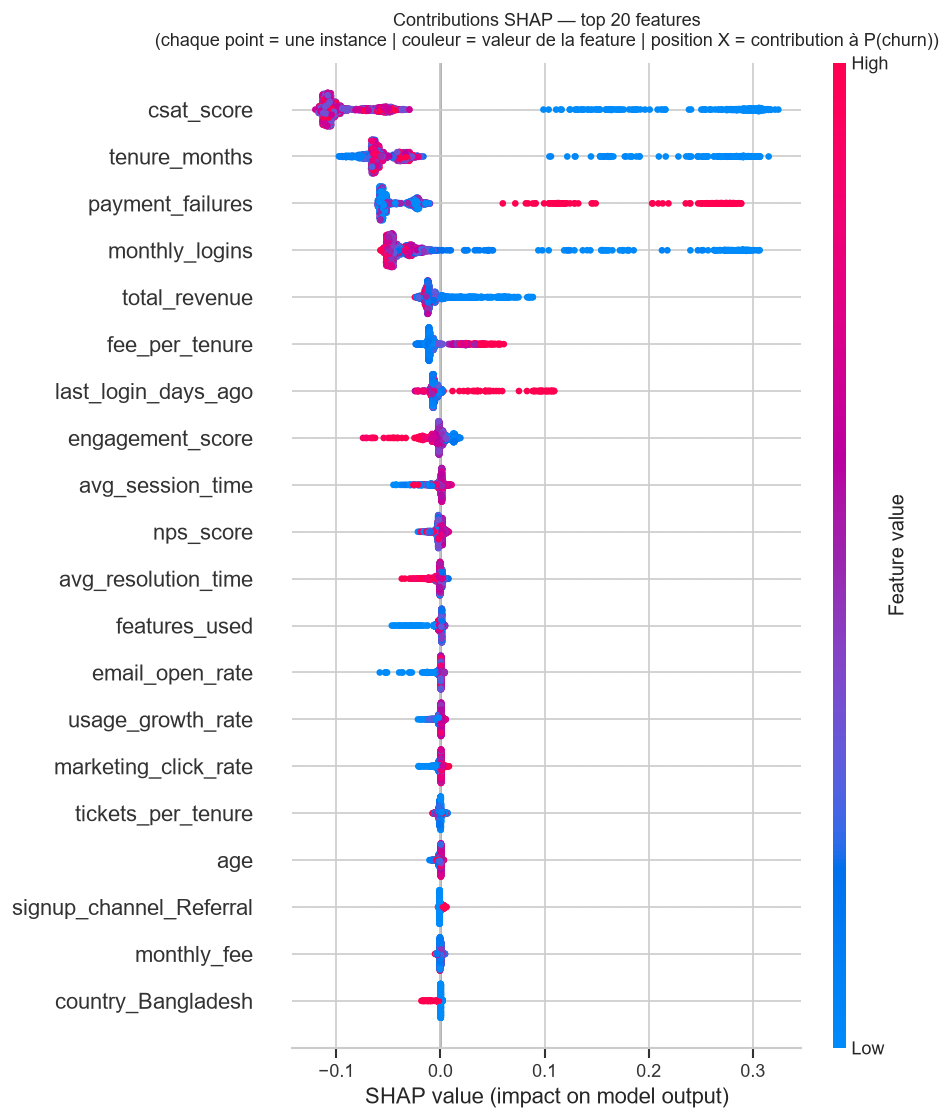


Top 15 features par contribution SHAP absolue moyenne :
   1. csat_score                          : 0.1203
   2. tenure_months                       : 0.0736
   3. payment_failures                    : 0.0620
   4. monthly_logins                      : 0.0551
   5. total_revenue                       : 0.0146
   6. fee_per_tenure                      : 0.0128
   7. last_login_days_ago                 : 0.0085
   8. engagement_score                    : 0.0068
   9. avg_session_time                    : 0.0033
  10. nps_score                           : 0.0027
  11. avg_resolution_time                 : 0.0024
  12. features_used                       : 0.0023
  13. email_open_rate                     : 0.0018
  14. usage_growth_rate                   : 0.0017
  15. marketing_click_rate                : 0.0016

Interprétation :
→ "csat_score" est la feature avec la plus forte contribution SHAP absolue moyenne (0.1203)
→ Cela signifie que cette feature modifie en moyenne le plus la préd

In [4]:
shap.initjs()

# Beeswarm — top 20 features par contribution absolue moyenne
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_explain,
    feature_names=FEATURE_NAMES,
    max_display=20,
    show=False,
    plot_type='dot',
)
plt.title(
    'Contributions SHAP — top 20 features\n'
    '(chaque point = une instance | couleur = valeur de la feature | position X = contribution à P(churn))',
    fontsize=11, pad=10
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_shap_beeswarm.png', bbox_inches='tight')
plt.show()

# Barplot d'importance globale (|SHAP| moyen)
mean_abs_shap = np.abs(shap_df).mean().sort_values(ascending=False).head(15)
print('\nTop 15 features par contribution SHAP absolue moyenne :')
for i, (feat, val) in enumerate(mean_abs_shap.items(), 1):
    print(f'  {i:2d}. {feat:35s} : {val:.4f}')

print('\nInterprétation :')
top1 = mean_abs_shap.index[0]
top1_val = mean_abs_shap.iloc[0]
print(f'→ "{top1}" est la feature avec la plus forte contribution SHAP absolue moyenne ({top1_val:.4f})')
print('→ Cela signifie que cette feature modifie en moyenne le plus la prédiction par rapport')
print('  à la valeur de base — dans un sens (churn) ou dans l\'autre (rétention).')

## 3. Explication individuelle : Waterfall Plot

Le waterfall décompose la prédiction d'**une instance spécifique** en contributions de chaque feature.

**Lecture :**
- On part de la **valeur de base** E[f(X)] (prédiction moyenne du modèle)
- Chaque barre ajoute ou soustrait la contribution de la feature
- On arrive à la **prédiction finale** f(x) pour ce client

On analyse deux cas : un churner détecté à très haut risque, et un churner manqué.

In [5]:
# Identifier les churners prédits (TP) et les churners manqués (FN) dans le sous-ensemble expliqué
y_explain = y_test[idx_sample]
proba_explain = best_proba_test[idx_sample]
pred_explain  = (proba_explain >= best_threshold).astype(int)

tp_idx = np.where((y_explain == 1) & (pred_explain == 1))[0]  # vrais positifs
fn_idx = np.where((y_explain == 1) & (pred_explain == 0))[0]  # faux négatifs

print(f'Churners détectés (TP) dans l\'ensemble expliqué : {len(tp_idx)}')
print(f'Churners manqués  (FN) dans l\'ensemble expliqué : {len(fn_idx)}')

Churners détectés (TP) dans l'ensemble expliqué : 104
Churners manqués  (FN) dans l'ensemble expliqué : 49


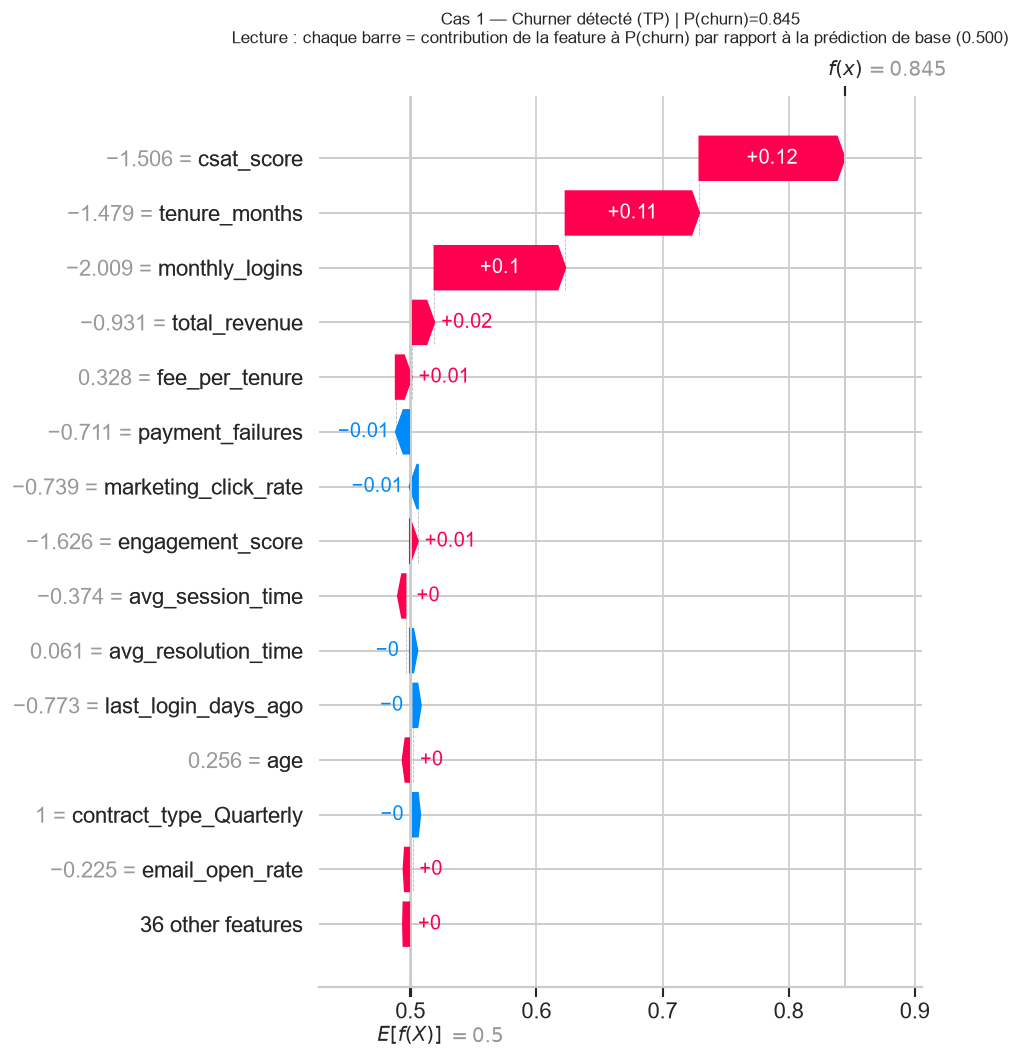

Interprétation (3 contributions dominantes pour ce client) :
  → csat_score = -1.51 : contribution SHAP = +0.1153 (augmente P(churn))
  → tenure_months = -1.48 : contribution SHAP = +0.1061 (augmente P(churn))
  → monthly_logins = -2.01 : contribution SHAP = +0.1040 (augmente P(churn))


In [6]:
# CAS 1 — Churner détecté à très haut risque (TP)
if len(tp_idx) > 0:
    # Prendre le TP avec la proba de churn la plus haute
    case_tp = tp_idx[np.argmax(proba_explain[tp_idx])]
    shap_exp_tp = shap.Explanation(
        values=shap_values[case_tp],
        base_values=base_value,
        data=X_explain[case_tp],
        feature_names=FEATURE_NAMES,
    )
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_exp_tp, max_display=15, show=False)
    plt.title(
        f'Cas 1 — Churner détecté (TP) | P(churn)={proba_explain[case_tp]:.3f}\n'
        f'Lecture : chaque barre = contribution de la feature à P(churn) '
        f'par rapport à la prédiction de base ({base_value:.3f})',
        fontsize=10, pad=10
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '04_shap_waterfall_tp.png', bbox_inches='tight')
    plt.show()

    # Interprétation textuelle des 3 principales contributions
    contribs = pd.Series(shap_values[case_tp], index=FEATURE_NAMES).sort_values(key=abs, ascending=False)
    print('Interprétation (3 contributions dominantes pour ce client) :')
    for feat, val in contribs.head(3).items():
        direction = 'augmente P(churn)' if val > 0 else 'réduit P(churn)'
        feat_val  = X_explain[case_tp, FEATURE_NAMES.index(feat)]
        print(f'  → {feat} = {feat_val:.2f} : contribution SHAP = {val:+.4f} ({direction})')

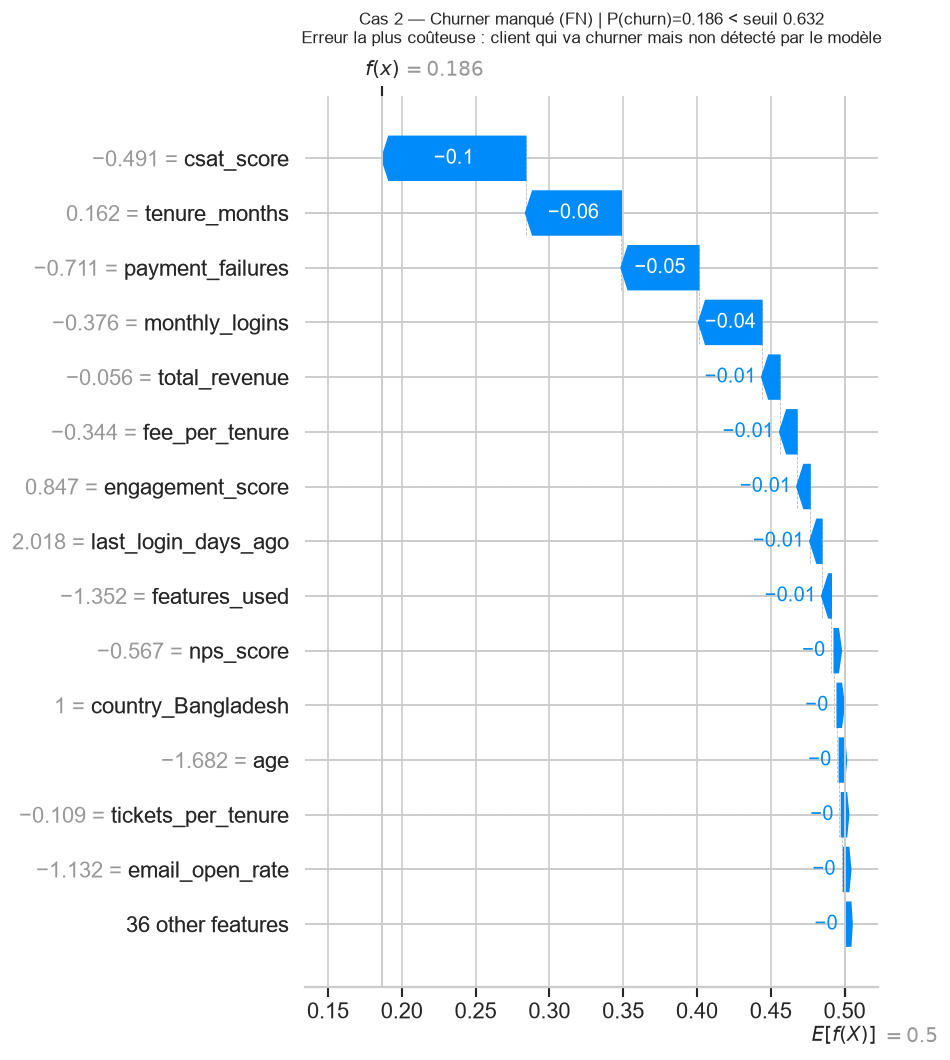

Pourquoi ce churner est-il manqué ?
Features qui contribuent à le classer comme NON-churner (contributions négatives) :
  → price_increase_last_3m_Yes = 0.00 : contribution = -0.0000 (pousse vers non-churn)
  → city_New York = 1.00 : contribution = -0.0000 (pousse vers non-churn)
  → city_Toronto = 0.00 : contribution = -0.0000 (pousse vers non-churn)

Mais en réalité ce client churne → le modèle est trompé par ces features "rassurantes"


In [7]:
# CAS 2 — Churner manqué (FN) — erreur la plus coûteuse métier
if len(fn_idx) > 0:
    case_fn = fn_idx[0]
    shap_exp_fn = shap.Explanation(
        values=shap_values[case_fn],
        base_values=base_value,
        data=X_explain[case_fn],
        feature_names=FEATURE_NAMES,
    )
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_exp_fn, max_display=15, show=False)
    plt.title(
        f'Cas 2 — Churner manqué (FN) | P(churn)={proba_explain[case_fn]:.3f} < seuil {best_threshold:.3f}\n'
        f'Erreur la plus coûteuse : client qui va churner mais non détecté par le modèle',
        fontsize=10, pad=10
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '04_shap_waterfall_fn.png', bbox_inches='tight')
    plt.show()

    # Comprendre pourquoi ce churner est manqué
    contribs_fn = pd.Series(shap_values[case_fn], index=FEATURE_NAMES).sort_values(ascending=False)
    print('Pourquoi ce churner est-il manqué ?')
    print('Features qui contribuent à le classer comme NON-churner (contributions négatives) :')
    for feat, val in contribs_fn[contribs_fn < 0].head(3).items():
        feat_val = X_explain[case_fn, FEATURE_NAMES.index(feat)]
        print(f'  → {feat} = {feat_val:.2f} : contribution = {val:+.4f} (pousse vers non-churn)')
    print('\nMais en réalité ce client churne → le modèle est trompé par ces features "rassurantes"')

## 4. Dependence Plot : Effet d'une feature sur les contributions SHAP

Le dependence plot montre comment la **valeur d'une feature** influence sa **contribution SHAP**.
La coloration par une deuxième feature révèle les effets d'interaction.

**Lecture :**
"Quand csat_score = 1, la contribution SHAP est fortement positive (le modèle est
poussé vers churn=1). Quand csat_score = 5, la contribution est négative.
La couleur (nps_score) montre que l'effet est amplifié pour les clients avec un NPS bas."

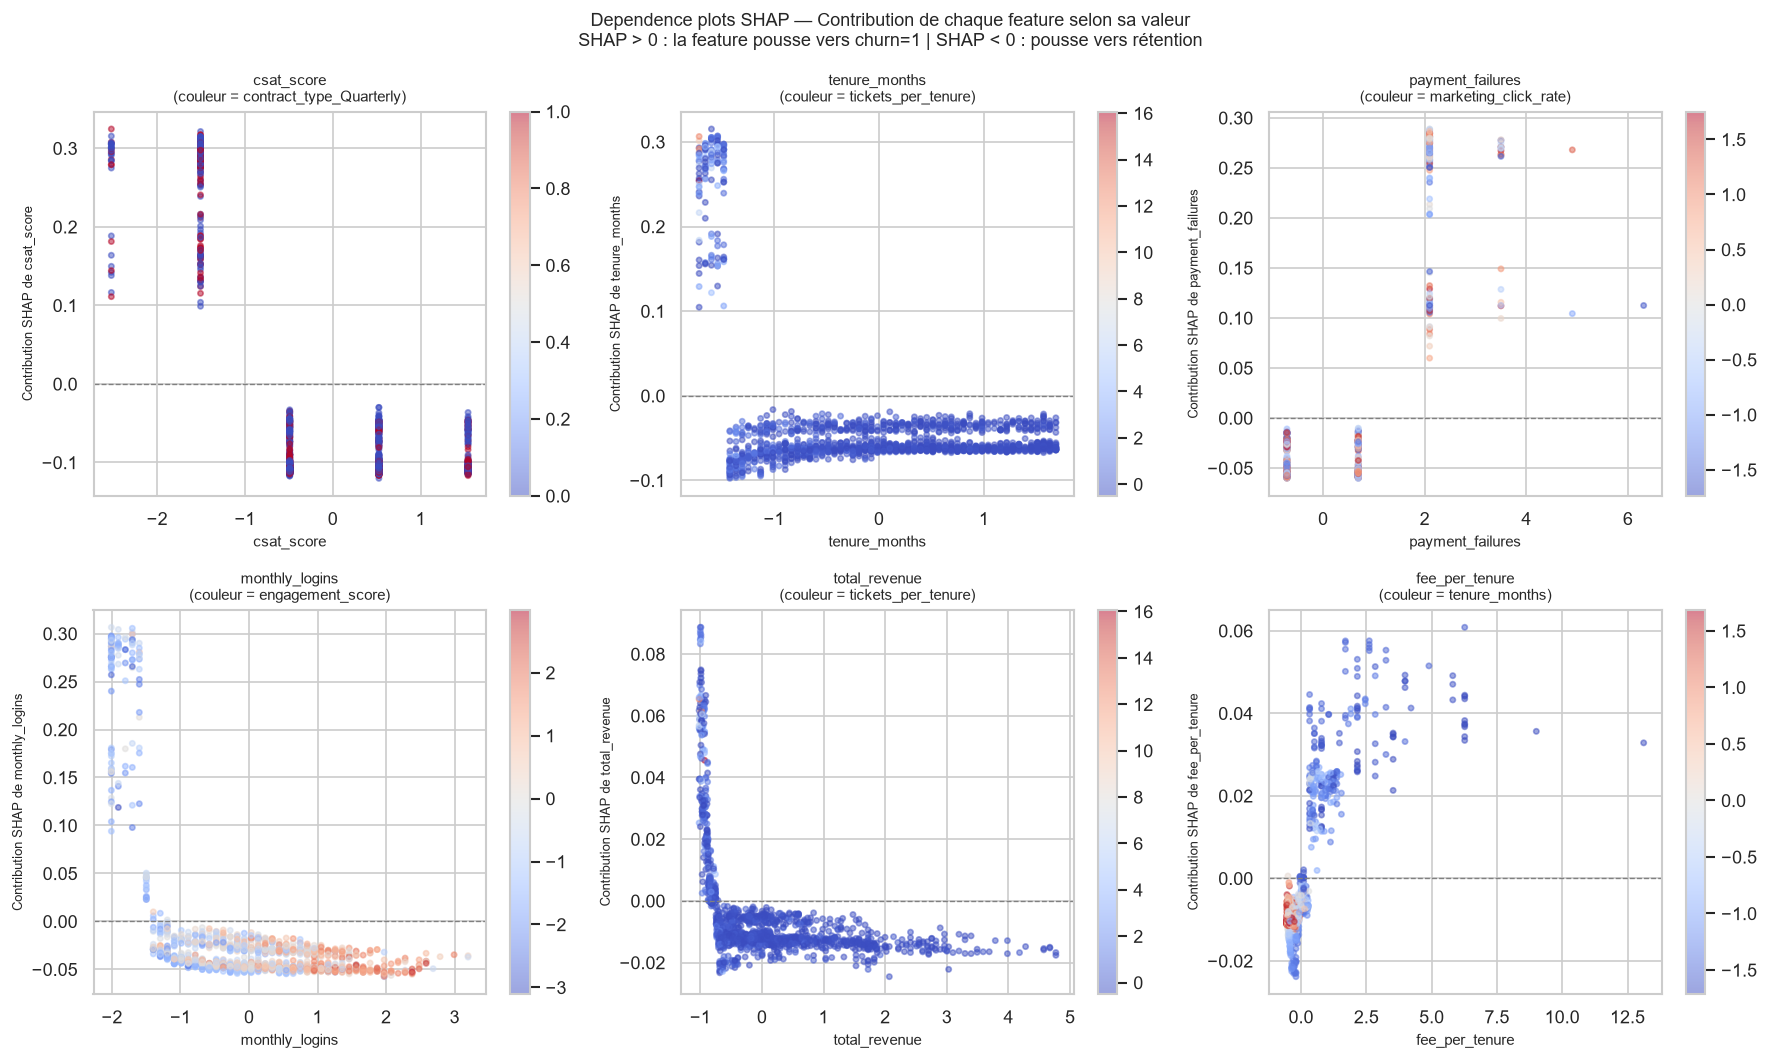

In [8]:
# Features d'intérêt pour les dependence plots
top_features = mean_abs_shap.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    if feat not in FEATURE_NAMES:
        continue
    feat_idx   = FEATURE_NAMES.index(feat)
    feat_vals  = X_explain[:, feat_idx]
    shap_vals_feat = shap_values[:, feat_idx]

    # Coloration par la 2e feature la plus corrélée aux SHAP values de cette feature
    corr_with_shap = np.abs(
        np.corrcoef(X_explain.T, shap_vals_feat)[:-1, -1]
    )
    color_feat_idx = np.argsort(corr_with_shap)[-2]  # 2e plus corrélée (la 1e est la feature elle-même)
    color_vals     = X_explain[:, color_feat_idx]

    sc = axes[i].scatter(
        feat_vals, shap_vals_feat,
        c=color_vals, cmap='coolwarm', alpha=0.5, s=10
    )
    axes[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel(f'Contribution SHAP de {feat}', fontsize=8)
    axes[i].set_title(f'{feat}\n(couleur = {FEATURE_NAMES[color_feat_idx]})', fontsize=9)
    plt.colorbar(sc, ax=axes[i])

plt.suptitle(
    'Dependence plots SHAP — Contribution de chaque feature selon sa valeur\n'
    'SHAP > 0 : la feature pousse vers churn=1 | SHAP < 0 : pousse vers rétention',
    fontsize=11
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_shap_dependence.png', bbox_inches='tight')
plt.show()

## 5. Synthèse : Ce que SHAP apporte au projet

### Importance globale (beeswarm)
Le beeswarm révèle quelles features **contribuent le plus** aux prédictions du modèle
en moyenne sur l'ensemble du test set. Ce n'est pas une corrélation avec le churn :
c'est la **sensibilité du modèle** à chaque variable.

### Explication individuelle (waterfall)
Pour chaque client, le waterfall permet de dire **pourquoi** le modèle prédit churn ou non.
C'est ce qui rend la solution actionnable pour l'équipe business :
"Ce client est à risque principalement à cause de son CSAT=1 et de ses 4 tickets support récents."

### Limites à mentionner
- SHAP mesure la contribution au modèle, pas la causalité dans le monde réel
- KernelSHAP (pour MLP) est une approximation — les valeurs peuvent varier légèrement
- Les interactions entre features sont partiellement capturées via les dependence plots
  mais restent difficiles à interpréter de manière exhaustive

In [9]:
# Tableau récapitulatif — top 10 features avec sens de la contribution
summary = []
for feat in mean_abs_shap.head(10).index:
    if feat not in FEATURE_NAMES:
        continue
    feat_idx   = FEATURE_NAMES.index(feat)
    vals       = X_explain[:, feat_idx]
    shap_f     = shap_values[:, feat_idx]
    corr       = np.corrcoef(vals, shap_f)[0, 1]
    mean_shap  = shap_f.mean()
    summary.append({
        'Feature': feat,
        '|SHAP| moyen': round(float(np.abs(shap_f).mean()), 4),
        'SHAP moyen':   round(float(mean_shap), 4),
        'Direction':    'Augmente P(churn)' if mean_shap > 0 else 'Réduit P(churn)',
        'Corrélation SHAP↔valeur': round(float(corr), 3),
    })

summary_df = pd.DataFrame(summary).set_index('Feature')
print('=== SYNTHÈSE SHAP — top 10 features ===')
print('Colonne "Direction" : sens de la contribution SHAP moyenne (pas une corrélation globale)')
print()
display(summary_df)


=== SYNTHÈSE SHAP — top 10 features ===
Colonne "Direction" : sens de la contribution SHAP moyenne (pas une corrélation globale)



,|SHAP| moyen,SHAP moyen,Direction,Corrélation SHAP↔valeur
Feature,,,,
csat_score,0.1203,-0.0401,Réduit P(churn),-0.689
tenure_months,0.0736,-0.0290,Réduit P(churn),-0.437
payment_failures,0.0620,-0.0215,Réduit P(churn),0.706
monthly_logins,0.0551,-0.0177,Réduit P(churn),-0.563
total_revenue,0.0146,-0.0034,Réduit P(churn),-0.439
fee_per_tenure,0.0128,-0.0035,Réduit P(churn),0.768
last_login_days_ago,0.0085,-0.0025,Réduit P(churn),0.562
engagement_score,0.0068,-0.0011,Réduit P(churn),-0.824
avg_session_time,0.0033,-0.0012,Réduit P(churn),0.456
